# Heat source recovery in a heated slab
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/optimization/solid/source_recovery_thermal.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/optimization/solid/source_recovery_thermal.ipynb)

We solve an *inverse* problem: given temperature observations on a heated slab, recover the volumetric heat source that produced them.

The forward model is steady-state heat conduction on a quasi-2D slab $\Omega = [0,2] \times [0,1] \times [0,1]$, discretized with a single layer of hexahedral elements:

$$\mathrm{div}\left(\kappa \, \mathrm{grad}(T)\right) + s = 0 \quad \in \Omega$$

with $T=0$ at $x=0$, a uniform heat flux $q_n = Q / (L_y L_z)$ at $x=2$, insulated boundaries elsewhere, and the SIMP-effective conductivity at uniform density $\rho = 0.5$. This is the same setup as the thermal benchmark in `benchmarks/thermal.py`, which mirrors the *thermal-mesh* problem of the [mosaic benchmark suite](https://github.com/pasteurlabs/mosaic).

We recover the per-element source field from nodal observations $T^*$ by minimizing the identification error $\lVert T(s) - T^* \rVert_2^2$, where gradients flow through the sparse FEM solve via `model.solve(differentiable_parameters=s)`.

In [1]:
import matplotlib.pyplot as plt
import torch

from torchfem import SolidHeat
from torchfem.materials import IsotropicConductivity3D
from torchfem.mesh import cube_hexa

torch.set_default_dtype(torch.float64)

LX, LY, LZ = 2.0, 1.0, 1.0  # domain
NX, NY = 32, 16  # elements in x and y (square in-plane)
KAPPA = 1e-3 + (1.0 - 1e-3) * 0.5**3  # SIMP conductivity at rho = 0.5
Q_TOTAL = 1.0  # total heat flux on the right face
NOISE = 0.0  # std of Gaussian noise on the observations

## Forward model

The Neumann flux is lumped to the right-face nodes with trapezoidal weights. The per-element source field $s$ is lumped to nodal loads as $s_e V_e / 8$, so gradients flow from the temperature field back to $s$.

In [2]:
nodes, elements = cube_hexa(NX + 1, NY + 1, 2, LX, LY, LZ)
model = SolidHeat(nodes, elements, IsotropicConductivity3D(kappa=KAPPA))

# Fixed temperature T=0 on the left face
model.constraints[nodes[:, 0] == 0.0, :] = True

# Uniform flux on the right face (trapezoidal weights, single layer in z)
w = torch.full((model.n_nod,), LY / NY * LZ / 2)
w[(nodes[:, 1] == 0.0) | (nodes[:, 1] == LY)] /= 2.0
right = nodes[:, 0] == LX
f_neumann = torch.zeros(model.n_nod)
f_neumann[right] = Q_TOTAL / (LY * LZ) * w[right]

centroids = nodes[elements].mean(dim=1)
vol_e = LX / NX * LY / NY * LZ


def solve_temperature(s):
    """Solve for nodal temperatures given a per-element source field s."""
    f_source = model.assemble_rhs((s * vol_e / 8).unsqueeze(1).expand(-1, 8))
    model.heat_flux = (f_neumann + f_source).unsqueeze(1)
    u, *_ = model.solve(differentiable_parameters=s)
    return u.ravel()

## Ground-truth source variants

Sources are defined on the element centroids — *two Gaussians* is the ground truth of mosaic's source-identification experiments. Feel free to add your own.

In [3]:
def gaussian(c, amplitude=1.0, cx=0.5, cy=0.5, sigma=0.2):
    w = sigma * min(LX, LY)
    r2 = (c[:, 0] - cx * LX) ** 2 + (c[:, 1] - cy * LY) ** 2
    return amplitude * torch.exp(-r2 / (2 * w**2))


def two_gaussians(c, amplitude=1.0, sigma=0.1):
    return gaussian(c, amplitude, 0.3, 0.5, sigma) + gaussian(
        c, amplitude, 0.7, 0.5, sigma
    )


def ring(c, amplitude=1.0, radius=0.3, width=0.08):
    d = torch.sqrt((c[:, 0] - LX / 2) ** 2 + (c[:, 1] - LY / 2) ** 2)
    return amplitude * torch.exp(-((d - radius) ** 2) / (2 * width**2))


variants = {
    "gaussian": gaussian(centroids),
    "two_gaussians": two_gaussians(centroids),
    "ring": ring(centroids),
}

The element order of `cube_hexa` on the single-layer slab is $e = i_x n_y + i_y$, so a per-element field maps to the image grid via `field.reshape(NX, NY).T`.

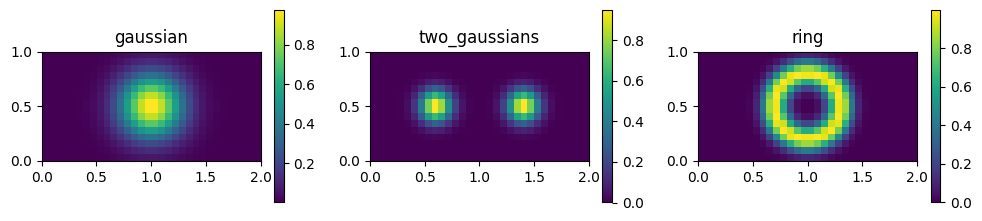

In [4]:
def show(ax, field, title, **kwargs):
    im = ax.imshow(
        field.reshape(NX, NY).T, origin="lower", extent=[0, LX, 0, LY], **kwargs
    )
    ax.set_title(title)
    plt.colorbar(im, ax=ax)


fig, axes = plt.subplots(1, len(variants), figsize=(12, 2.5))
for ax, (name, s_true) in zip(axes, variants.items()):
    show(ax, s_true, name)
plt.show()

## Synthetic observations

A forward solve per variant generates the nodal observations $T^*$ (optionally with Gaussian noise).

In [5]:
observations = {
    name: solve_temperature(s).detach() + NOISE * torch.randn(model.n_nod)
    for name, s in variants.items()
}

## Recovery

Starting from $s = 0$, L-BFGS minimizes the identification error — each closure call is one forward solve and a backward pass through it. (Adam works too, but needs many more iterations.)

In [6]:
def recover(T_target):
    s = torch.zeros(model.n_elem, requires_grad=True)
    optimizer = torch.optim.LBFGS([s], max_iter=100, line_search_fn="strong_wolfe")
    losses = []

    def closure():
        optimizer.zero_grad()
        loss = ((solve_temperature(s) - T_target) ** 2).sum()
        loss.backward()
        losses.append(loss.item())
        return loss

    optimizer.step(closure)
    return s.detach(), losses


recovered, histories = {}, {}
for name, T_target in observations.items():
    recovered[name], histories[name] = recover(T_target)
    error = (recovered[name] - variants[name]).norm() / variants[name].norm()
    print(f"{name}: {len(histories[name])} solves, rel. L2 error {error:.1e}")

gaussian: 59 solves, rel. L2 error 9.2e-04
two_gaussians: 77 solves, rel. L2 error 6.8e-03
ring: 105 solves, rel. L2 error 5.2e-03


## Results

Note: Observations are generated on the recovery mesh itself (an *inverse crime*). Noisy or subsampled observations (`NOISE > 0`, or a loss over a node subset) make the problem ill-posed and call for regularization, e.g. a Tikhonov term $\alpha \lVert s \rVert^2$.

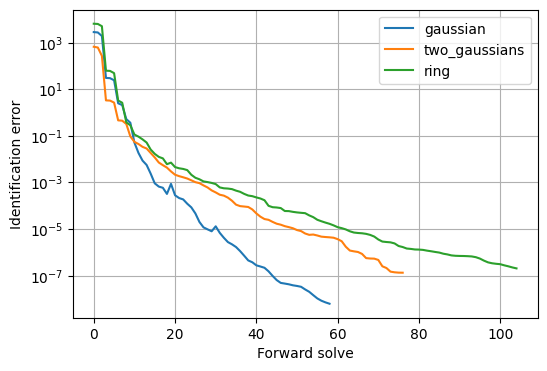

In [7]:
plt.figure(figsize=(6, 4))
for name, losses in histories.items():
    plt.semilogy(losses, label=name)
plt.xlabel("Forward solve")
plt.ylabel("Identification error")
plt.legend()
plt.grid()
plt.show()

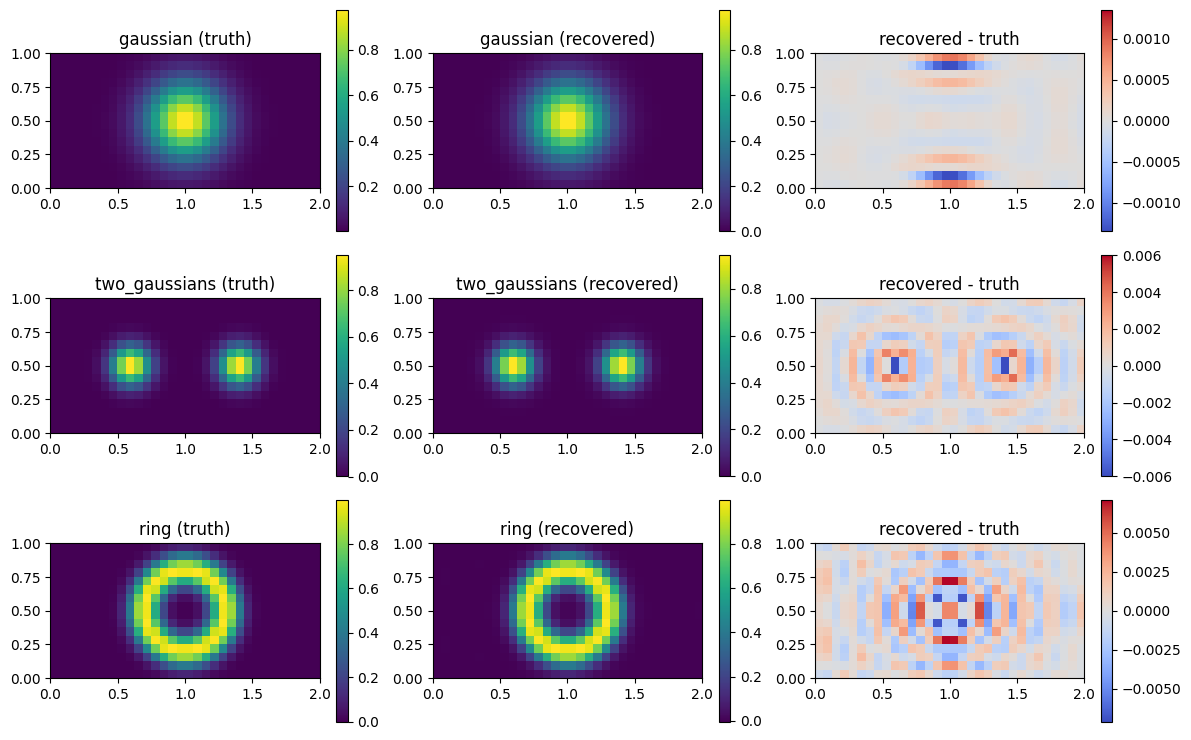

In [8]:
fig, axes = plt.subplots(len(variants), 3, figsize=(12, 2.5 * len(variants)))
for row, name in zip(axes, variants):
    diff = recovered[name] - variants[name]
    lim = float(diff.abs().max())
    show(row[0], variants[name], f"{name} (truth)")
    show(row[1], recovered[name], f"{name} (recovered)")
    show(row[2], diff, "recovered - truth", cmap="coolwarm", vmin=-lim, vmax=lim)
plt.tight_layout()
plt.show()